# Objectives

##  Compare the definition of best matches and weak best matches

### Check whether every best match in $(N, \sigma)$ is also a weak best match. Test this computationally, but also try to give a formal argument.

Wie bereits in der Aufgabenstellung beschrieben, erstellen wir ein neues Set, welches die Menge aller last common ancestors zwischen einem bestimmten Blatt und einer anderen Farbe darstellt.
Für alle $x \in L(N)$ und $\tau \in \sigma(L(N)\backslash x)$ definieren wir:
$$Q(x,\tau) \coloneqq \min_{\preceq} \{v\in lca(x,y):\sigma(y) = \tau\}$$
Für die *weak* best matches haben wir dabei bereits folgendes definiert: Gilt für ein Netzwerk $N$: $x,y\in L(N), \, \sigma (y) \ne \sigma(x)$, dann ist $y$ ein *weak* best match von $x$ wenn gilt: $lca(x,y) \cap Q(x,\sigma(y)) \ne \varnothing$.

Die Anforderung ist also, dass die Menge der last common ancestors von x und y eine Schnittmenge bildet mit der Menge Q.

Für die *strong* best matches definieren wir: Gilt für ein Netzwerk $N$: $x,y\in L(N), \, \sigma (y) \ne \sigma(x)$, dann ist $y$ ein *strong* best match von $x$ wenn gilt: $LCA(x,y) \subseteq Q(x,\sigma(y))$ und $u \nprec v \, \forall u \in Q(x,\sigma(y)), \forall v\in LCA (x,y)$. Sprich, es gilt die Bedingung für weak best matches, und die Zusatzbedingung dass die Menge der last common ancestors keine Node enthalten dürfen, die über irgendeiner node in Q liegt.

Die formale Definition zeigt direkt, dass alle strong best matches auch weak best matches sind, aber dass das nicht zwingend umgekehrt gelten muss. 

Beispiel aus dem Netzwerk paper, welches zeigt dass strong best matches auch weak best matches sind, aber nicht umgekehrt.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import asymmetree.treeevolve as te
import random
import numpy as np

from networkx.drawing.nx_pydot import graphviz_layout
from bmg_Tony import bmg
from BICcherryRestrict import BICcherryRestrict
from BICcherry_reverse import BICcherry_reverse
from asymmetree.visualization.tree_vis import visualize, assign_colors

In [2]:
def layered_layout(G: nx.DiGraph):
    """Einfaches Ebenen-Layout fuer DAGs (Wurzel oben, Blaetter unten)."""
    pos = {}
    for depth, generation in enumerate(nx.topological_generations(G)):
        gen = list(generation)
        for j, node in enumerate(gen):
            pos[node] = (j - len(gen) / 2, -depth)
    return pos

# Some graphs don't originate from networks

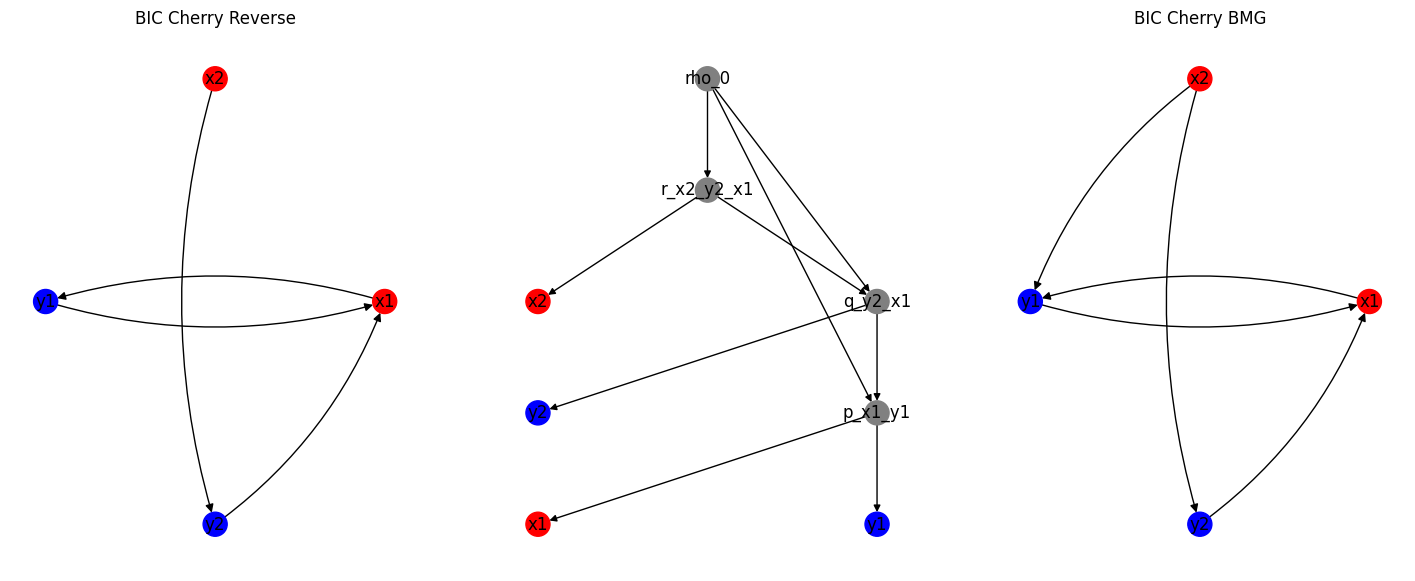

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

"""
network = nx.DiGraph()
network.add_nodes_from([("x1", {"color": "red"}), ("x2", {"color": "red"}), ("y1", {"color": "blue"}), ("y2", {"color": "blue"}), ("y3", {"color": "blue"})])
network.add_edges_from([("rho", "p1"), ("rho", "p2"), ("p1", "x2"), ("p1", "p3"), ("p2" ,"y3"), ("p2" ,"x1"),
                           ("p3", "y2"), ("p3", "p4"), ("p4", "y1"), ("p4", "x1")])
"""

BMG = nx.DiGraph()
BMG.add_nodes_from([("x1", {"color": "red"}), ("x2", {"color": "red"}), ("y1", {"color": "blue"}), ("y2", {"color": "blue"})])
BMG.add_edges_from([("x1", "y1"), ("y1", "x1"), ("y2", "x1"), ("x2", "y2")])

pos_BMG = nx.circular_layout(BMG)
nodes_list, nodes_colors = zip(*BMG.nodes(data="color", default="grey"))
nx.draw(BMG, pos_BMG, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0], with_labels=True, arrows=True, arrowsize=12,
        connectionstyle="arc3,rad=0.15",)
axes[0].set_title("Input BMG")

bic_cherry_reverse = BICcherry_reverse(BMG, simplify=True)

bcr_copy = bic_cherry_reverse.copy()
bcr_copy.add_nodes_from(['1','2','3'])
bcr_copy.add_edges_from([('rho_0','1'),('1','r_x2_y2_x1'),('1','y1')])

bcr_copy.add_edges_from([('2','r_x2_y2_x1'),('2','x2'),('1','y1')])
bcr_copy.add_edges_from([('r_x2_y2_x1','3'),('3','x2'),('3','y1')])
# bcr_copy.remove_edge('rho_0','r_x2_y2_x1')


# pos = layered_layout(bcr_copy)
# nodes_list, nodes_colors = zip(*bcr_copy.nodes(data="color", default="grey"))
# nx.draw(bcr_copy, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels = True)
# axes[0].set_title("BIC Cherry Reverse")

pos = layered_layout(bic_cherry_reverse)
nodes_list, nodes_colors = zip(*bic_cherry_reverse.nodes(data="color", default="grey"))
nx.draw(bic_cherry_reverse, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels = True)
axes[0].set_title("BIC Cherry Reverse")



network_bmg = bmg(bic_cherry_reverse, mode="strong")
#pos = nx.spring_layout(network_bmg)
nodes_list, nodes_colors = zip(*network_bmg.nodes(data="color", default="grey"))
nx.draw(network_bmg, pos_BMG, nodelist=nodes_list, node_color= nodes_colors, ax=axes[2], with_labels=True, arrows=True, arrowsize=12,
        connectionstyle="arc3,rad=0.15",)
axes[2].set_title("BIC Cherry BMG")

fig.savefig("../Presentation/figures/graph_input_fail.svg", bbox_inches="tight")

# Example network that always breaks with the traditional BIC Cherry

In [19]:
network = nx.DiGraph()
network.add_nodes_from([("x1", {"color": "red"}), ("x2", {"color": "red"}), ("y1", {"color": "blue"}), ("y2", {"color": "blue"})])
network.add_edges_from([("rho", "p1"), ("rho", "p2"), ("p1", "y2"), ("p1", "p3"), ("p2" ,"p3"),
                           ("p2", "x1"), ("p3", "x2"), ("p3", "y1")])

Text(0.5, 1.0, 'Weak BMG')

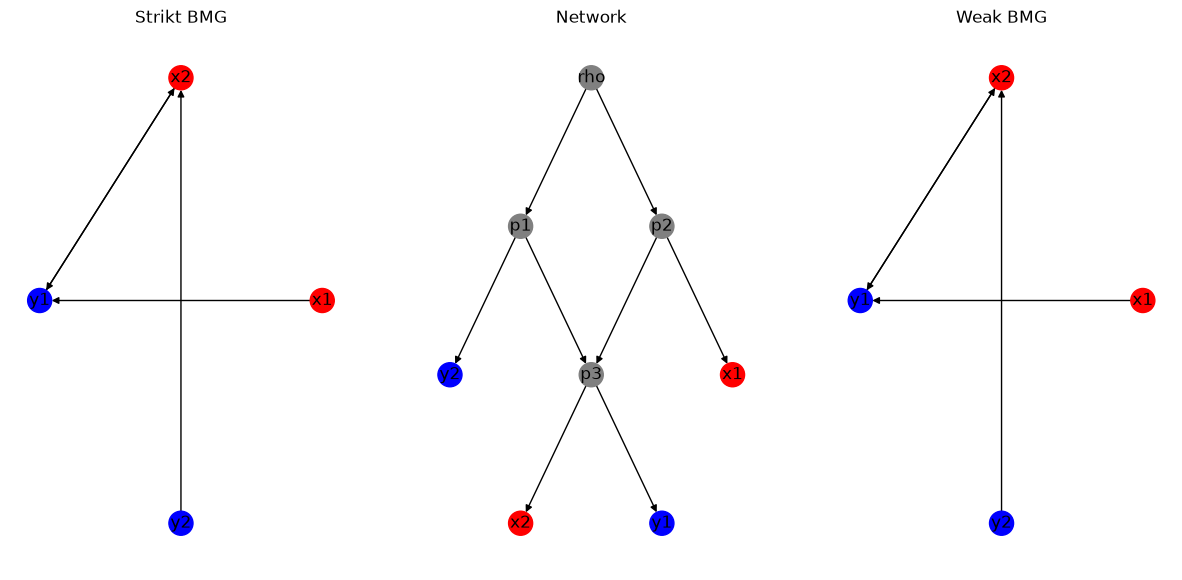

In [20]:
# figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
pos = graphviz_layout(network, prog="dot")
nodes_list, nodes_colors = zip(*network.nodes(data="color", default="grey"))
nx.draw(network, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels = True)
axes[1].set_title("Network")

# strong bmg
strong_bmg = bmg(network, mode="strong")
pos = nx.circular_layout(strong_bmg)
nodes_list, nodes_colors = zip(*strong_bmg.nodes(data="color", default="grey"))
nx.draw(strong_bmg, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0], with_labels=True)
axes[0].set_title("Strikt BMG")

# weak BMG
weak_bmg = bmg(network, mode="weak")
nx.draw(weak_bmg, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[2], with_labels=True)
axes[2].set_title("Weak BMG")

In [21]:
bic_cherry_reverse = BICcherry_reverse(weak_bmg, simplify=True)
weak_bic_cherry_reverse = bmg(bic_cherry_reverse, mode="weak")
print("The two BMGs are equal: ", nx.utils.graphs_equal(weak_bmg, weak_bic_cherry_reverse))
bic_cherry_restrict = BICcherryRestrict(weak_bmg)
weak_bic_cherry_restrict = bmg(bic_cherry_restrict, mode="weak")

The two BMGs are equal:  True


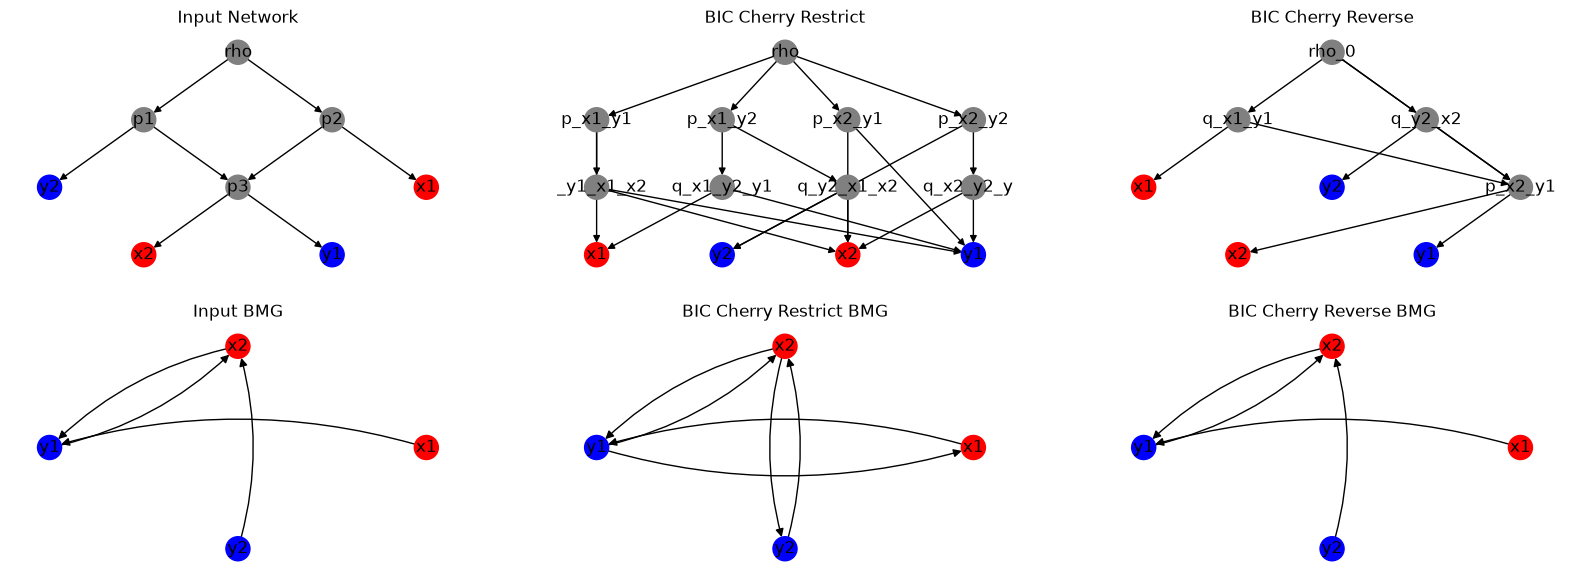

In [22]:
# figure with three subplots
fig, axes = plt.subplots(2, 3, figsize=(20, 7))
# first row is networks
# starting network
pos = layered_layout(network)
nodes_list, nodes_colors = zip(*network.nodes(data="color", default="grey"))
nx.draw(network, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0,0], with_labels = True)
axes[0,0].set_title("Input Network")

# biccherry restrict network
pos = layered_layout(bic_cherry_restrict)
nodes_list, nodes_colors = zip(*bic_cherry_restrict.nodes(data="color", default="grey"))
nx.draw(bic_cherry_restrict, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0,1], with_labels = True)
axes[0,1].set_title("BIC Cherry Restrict")

# new bic cherry reverse network
pos = layered_layout(bic_cherry_reverse)
nodes_list, nodes_colors = zip(*bic_cherry_reverse.nodes(data="color", default="grey"))
nx.draw(bic_cherry_reverse, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0,2], with_labels = True)
axes[0,2].set_title("BIC Cherry Reverse")

# second row are their BMGs
# input BMG
#strong_bmg = bmg(test_graph, mode="strong")
pos = nx.circular_layout(weak_bmg)
nodes_list, nodes_colors = zip(*weak_bmg.nodes(data="color", default="grey"))
nx.draw(weak_bmg, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,0], with_labels=True, arrows=True, arrowsize=12,
        connectionstyle="arc3,rad=0.15",)
axes[1,0].set_title("Input BMG")

# biccherry weak
#weak_bmg = bmg(test_graph, mode="weak")
nx.draw(weak_bic_cherry_restrict, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,1], with_labels=True, arrows=True, arrowsize=12,
        connectionstyle="arc3,rad=0.15",)
axes[1,1].set_title("BIC Cherry Restrict BMG")

# new bic cherry reverse BMG
nx.draw(weak_bic_cherry_reverse, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,2], with_labels=True, arrows=True, arrowsize=12,
        connectionstyle="arc3,rad=0.15",)
axes[1,2].set_title("BIC Cherry Reverse BMG")

fig.savefig("../Presentation/figures/comp_restricted_reverse.svg", bbox_inches="tight")

# Network and its BMG to highlight how the new algorithm works

In [8]:
import matplotlib.pyplot as plt
import networkx as nx


def draw_bmg_highlight(G, pos, ax, highlight=(), title=None,
                       node_size=300, highlight_color="red"):
    """Zeichnet ein BMG. Die Kanten werden in zwei getrennte Mengen
    aufgeteilt: alle Kanten, die NICHT in `highlight` sind, normal in
    Schwarz, und die Kanten aus `highlight` nur einmal, in Rot.

    highlight : Graph oder Iterable von Kanten (u, v)
    """
    highlight = set(highlight.edges() if isinstance(highlight, nx.Graph) else highlight)
    normal = [e for e in G.edges() if e not in highlight]
    red = [e for e in highlight if e[0] in pos and e[1] in pos]

    nodes = list(G.nodes())
    colors = [G.nodes[n].get("color", "grey") for n in nodes]
    nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=colors,
                           node_size=node_size, ax=ax)
    nx.draw_networkx_labels(G, pos, ax=ax)

    style = dict(ax=ax, arrows=True, arrowsize=12, node_size=node_size,
                 connectionstyle="arc3,rad=0.15")
    nx.draw_networkx_edges(G, pos, edgelist=normal, edge_color="black", **style)
    nx.draw_networkx_edges(G, pos, edgelist=red, edge_color=highlight_color,
                           width=2.5, **style)
    ax.set_axis_off()
    if title:
        ax.set_title(title)


def draw_network_new_nodes(net, pos, ax, old_nodes=(), title=None,
                           new_color="orange", internal_color="grey",
                           node_size=300):
    """Zeichnet ein Netzwerk in EINEM Aufruf (kein doppeltes Zeichnen).

    Knotenfarbe:
      - Blaetter (Knoten mit "color"-Attribut) behalten ihre eigene Farbe,
        auch wenn sie neu sind;
      - neue innere Knoten (nicht in `old_nodes`) werden `new_color`;
      - alle uebrigen inneren Knoten `internal_color`.
    """
    old_nodes = set(old_nodes)
    nodes = list(net.nodes())
    colors = []
    for n in nodes:
        if "color" in net.nodes[n]:
            colors.append(net.nodes[n]["color"])
        elif n not in old_nodes:
            colors.append(new_color)
        else:
            colors.append(internal_color)
    nx.draw(net, pos, nodelist=nodes, node_color=colors, node_size=node_size,
            ax=ax, with_labels=True)
    if title:
        ax.set_title(title)

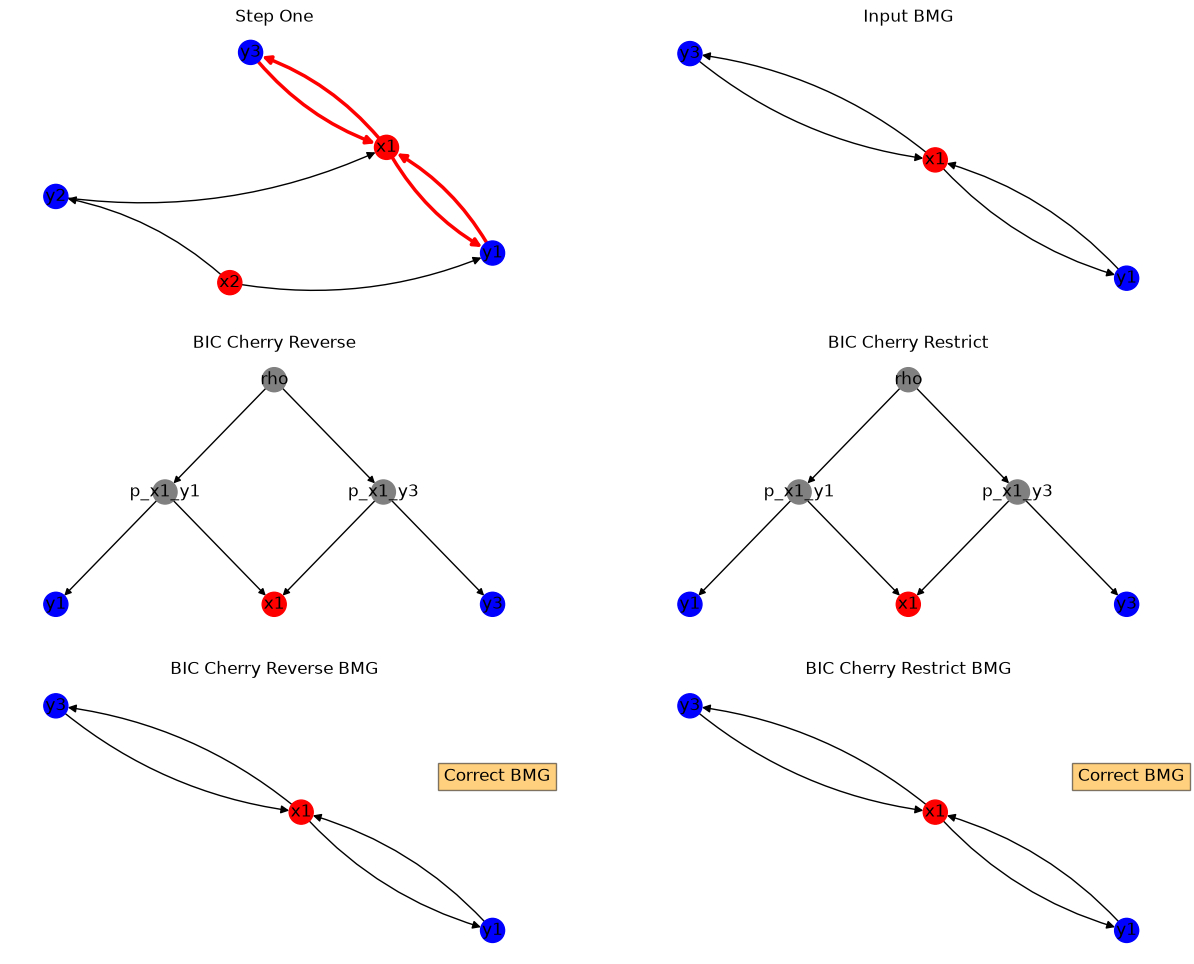

In [12]:
# STEP ONE
# figure with three subplots
network = nx.DiGraph()
network.add_nodes_from([("x1", {"color": "red"}), ("x2", {"color": "red"}), ("y1", {"color": "blue"}), ("y2", {"color": "blue"}), ("y3", {"color": "blue"})])
network.add_edges_from([("rho", "p1"), ("rho", "p2"), ("p1", "x2"), ("p1", "p3"), ("p2" ,"y3"), ("p2" ,"x1"),
                           ("p3", "y2"), ("p3", "p4"), ("p4", "y1"), ("p4", "x1")])

fig, axes = plt.subplots(3, 2, figsize=(15, 12))

input_BMG = nx.DiGraph()
input_BMG.add_nodes_from([("x1", {"color": "red"}), ("y1", {"color": "blue"}), ("y3", {"color": "blue"})])
input_BMG.add_edges_from([("x1", "y1"), ("y1", "x1"), ("x1", "y3"), ("y3", "x1")])

# erste Reihe: links der input BMG, mit den edges in Rot, um die es geht
network_bmg = bmg(network, mode="weak")
pos_BMG = nx.spring_layout(network_bmg)
nodes_list, nodes_colors = zip(*network_bmg.nodes(data="color", default="grey"))
draw_bmg_highlight(network_bmg, pos_BMG, axes[0,0], highlight=input_BMG, title="Step One")

# input BMG
nodes_list, nodes_colors = zip(*input_BMG.nodes(data="color", default="grey"))
nx.draw(input_BMG, pos_BMG, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0,1], with_labels=True, arrows=True, arrowsize=12,
        connectionstyle="arc3,rad=0.15",)
axes[0,1].set_title("Input BMG")

# zweite Reihe: BICcherrys, links neu (reverse), rechts restrict
# new bic cherry reverse network
bic_cherry_reverse = BICcherry_reverse(input_BMG)
pos = layered_layout(bic_cherry_reverse)
nodes_list, nodes_colors = zip(*bic_cherry_reverse.nodes(data="color", default="grey"))
nx.draw(bic_cherry_reverse, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,0], with_labels = True)
axes[1,0].set_title("BIC Cherry Reverse")
reverse_nodes = list(bic_cherry_reverse.nodes())

# biccherry restrict network
bic_cherry_restrict = BICcherryRestrict(input_BMG)
pos = layered_layout(bic_cherry_restrict)
nodes_list, nodes_colors = zip(*bic_cherry_restrict.nodes(data="color", default="grey"))
nx.draw(bic_cherry_restrict, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,1], with_labels = True)
axes[1,1].set_title("BIC Cherry Restrict")
restrict_nodes = list(bic_cherry_restrict.nodes())

# zweite Reihe: BMGs, links neu (reverse), rechts restrict
# new bic cherry reverse BMG
# new bic cherry reverse BMG
weak_bic_cherry_reverse = bmg(bic_cherry_reverse, mode="weak")
#pos = nx.circular_layout(weak_bic_cherry_reverse)
nodes_list, nodes_colors = zip(*weak_bic_cherry_reverse.nodes(data="color", default="grey"))
nx.draw(weak_bic_cherry_reverse, pos_BMG, nodelist=nodes_list, node_color= nodes_colors, ax=axes[2,0], with_labels=True, arrows=True, arrowsize=12,
        connectionstyle="arc3,rad=0.15",)
axes[2,0].set_title("BIC Cherry Reverse BMG")
if nx.utils.graphs_equal(weak_bic_cherry_reverse, input_BMG):
    text = "Correct BMG"
else:
    text = "Wrong BMG"
axes[2,0].text(0.6, 0.5,text, bbox=dict(facecolor='orange', alpha=0.5), fontsize=12)

# biccherry restrict
weak_bic_cherry_restrict = bmg(bic_cherry_restrict, mode="weak")
nx.draw(weak_bic_cherry_restrict, pos_BMG, nodelist=nodes_list, node_color= nodes_colors, ax=axes[2,1], with_labels=True, arrows=True, arrowsize=12,
        connectionstyle="arc3,rad=0.15",)
axes[2,1].set_title("BIC Cherry Restrict BMG")
if nx.utils.graphs_equal(weak_bic_cherry_restrict, input_BMG):
    text = "Correct BMG"
else:
    text = "Wrong BMG"
axes[2,1].text(0.6, 0.5,text, bbox=dict(facecolor='orange', alpha=0.5), fontsize=12)

fig.savefig("../Presentation/figures/reverse_bic_step_one.svg", bbox_inches="tight")
#FIG_DIR = "../Presentation/figures"
#plot_steps_boxplot(rows, save_path=f"{FIG_DIR}/network_steps_runs{RUNS}_seed{SEED}.svg")

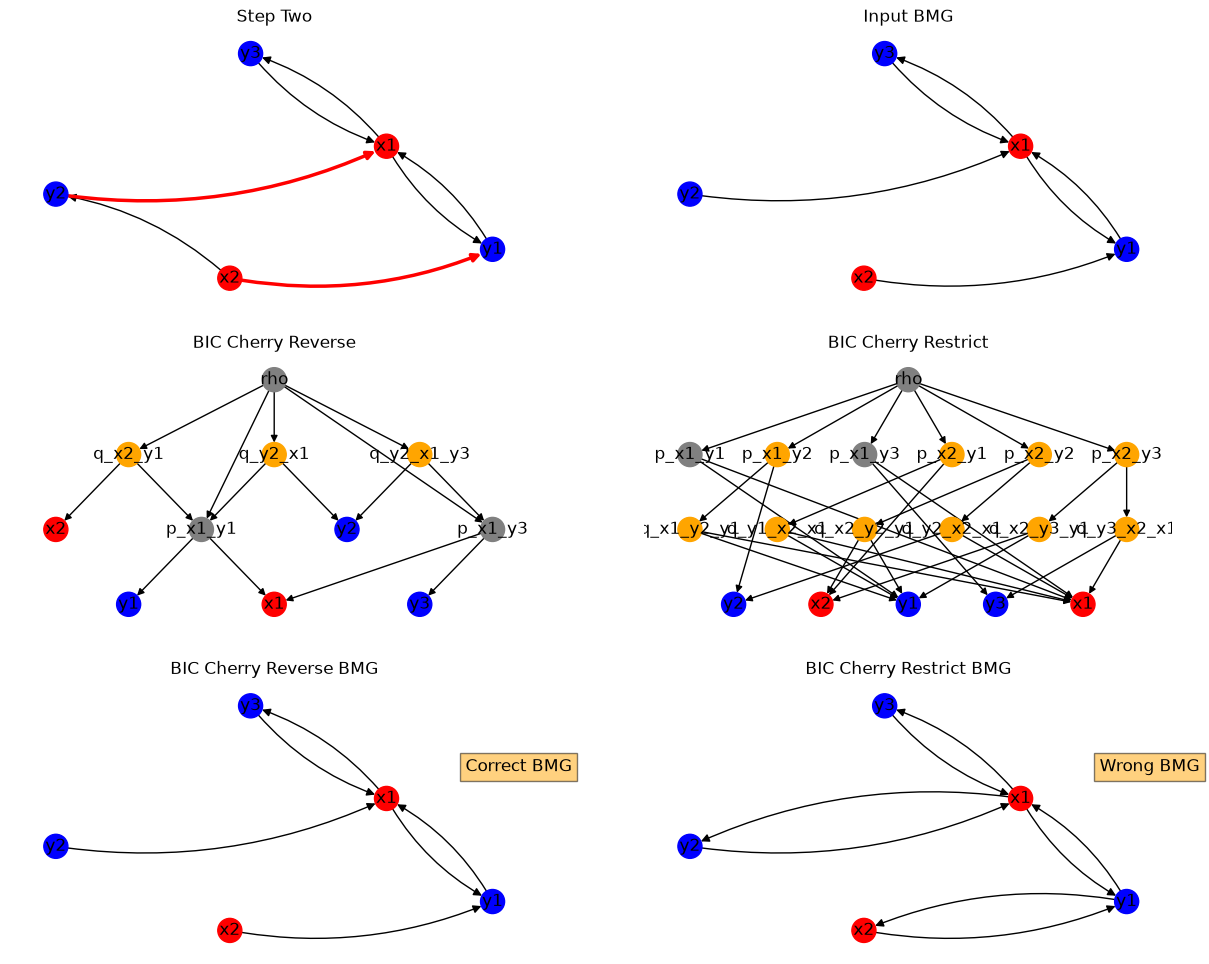

In [13]:
# STEP TWO
# figure with three subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

input_BMG = nx.DiGraph()
input_BMG.add_nodes_from([("x1", {"color": "red"}), ("x2", {"color": "red"}), ("y1", {"color": "blue"}), ("y2", {"color": "blue"}), ("y3", {"color": "blue"})])
input_BMG.add_edges_from([("x1", "y1"), ("y1", "x1"), ("x1", "y3"), ("y3", "x1"),
                        ("y2", "x1"), ("x2", "y1")])

edge_graph = nx.DiGraph()
edge_graph.add_nodes_from([("x1", {"color": "red"}), ("x2", {"color": "red"}), ("y1", {"color": "blue"}), ("y2", {"color": "blue"}), ("y3", {"color": "blue"})])
edge_graph.add_edges_from([("y2", "x1"), ("x2", "y1")])
# erste Reihe: links der input BMG, mit den edges in Rot, um die es geht
#pos = nx.spring_layout(network_bmg)
nodes_list, nodes_colors = zip(*network_bmg.nodes(data="color", default="grey"))
draw_bmg_highlight(network_bmg, pos_BMG, axes[0,0], highlight=edge_graph, title="Step Two")

# input BMG
nodes_list, nodes_colors = zip(*input_BMG.nodes(data="color", default="grey"))
nx.draw(input_BMG, pos_BMG, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0,1], with_labels=True, arrows=True, arrowsize=12,
        connectionstyle="arc3,rad=0.15",)
axes[0,1].set_title("Input BMG")

# zweite Reihe: BICcherrys, links neu (reverse), rechts restrict
# new bic cherry reverse network
bic_cherry_reverse = BICcherry_reverse(input_BMG)
pos = layered_layout(bic_cherry_reverse)
nodes_list, nodes_colors = zip(*bic_cherry_reverse.nodes(data="color", default="grey"))
draw_network_new_nodes(bic_cherry_reverse, layered_layout(bic_cherry_reverse), axes[1,0],
                       old_nodes=reverse_nodes, title="BIC Cherry Reverse")
reverse_nodes = list(bic_cherry_reverse.nodes())

# biccherry restrict network
bic_cherry_restrict = BICcherryRestrict(input_BMG)
pos = layered_layout(bic_cherry_restrict)
nodes_list, nodes_colors = zip(*bic_cherry_restrict.nodes(data="color", default="grey"))
draw_network_new_nodes(bic_cherry_restrict, layered_layout(bic_cherry_restrict), axes[1,1],
                       old_nodes=restrict_nodes, title="BIC Cherry Restrict")
restrict_nodes = list(bic_cherry_restrict.nodes())

# zweite Reihe: BMGs, links neu (reverse), rechts restrict
# new bic cherry reverse BMG
# new bic cherry reverse BMG
weak_bic_cherry_reverse = bmg(bic_cherry_reverse, mode="weak")
#pos = nx.circular_layout(weak_bic_cherry_reverse)
nodes_list, nodes_colors = zip(*weak_bic_cherry_reverse.nodes(data="color", default="grey"))
nx.draw(weak_bic_cherry_reverse, pos_BMG, nodelist=nodes_list, node_color= nodes_colors, ax=axes[2,0], with_labels=True, arrows=True, arrowsize=12,
        connectionstyle="arc3,rad=0.15",)
axes[2,0].set_title("BIC Cherry Reverse BMG")
if nx.utils.graphs_equal(weak_bic_cherry_reverse, input_BMG):
    text = "Correct BMG"
else:
    text = "Wrong BMG"
axes[2,0].text(0.6, 0.5,text, bbox=dict(facecolor='orange', alpha=0.5), fontsize=12)

# biccherry restrict
weak_bic_cherry_restrict = bmg(bic_cherry_restrict, mode="weak")
nx.draw(weak_bic_cherry_restrict, pos_BMG, nodelist=nodes_list, node_color= nodes_colors, ax=axes[2,1], with_labels=True, arrows=True, arrowsize=12,
        connectionstyle="arc3,rad=0.15",)
axes[2,1].set_title("BIC Cherry Restrict BMG")
if nx.utils.graphs_equal(weak_bic_cherry_restrict, input_BMG):
    text = "Correct BMG"
else:
    text = "Wrong BMG"
axes[2,1].text(0.6, 0.5,text, bbox=dict(facecolor='orange', alpha=0.5), fontsize=12)

fig.savefig("../Presentation/figures/reverse_bic_step_two.svg", bbox_inches="tight")

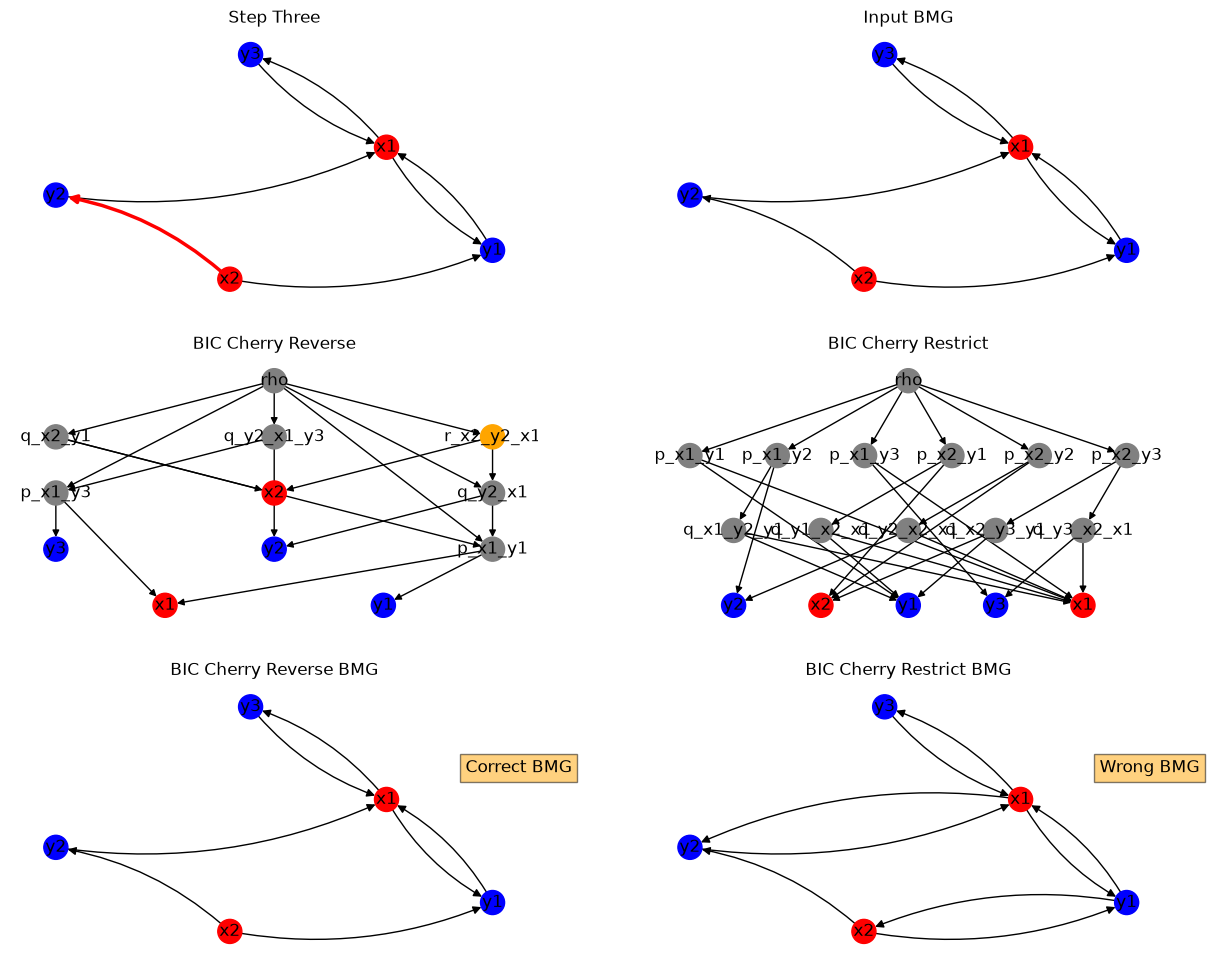

In [14]:
# STEP TWO
# figure with three subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# merge the top row into a single axis
#gs = axes[0, 0].get_gridspec()
#for ax in axes[0, :]:
#    ax.remove()
#ax_top = fig.add_subplot(gs[0, :])

input_BMG = network_bmg

edge_graph = nx.DiGraph()
edge_graph.add_nodes_from([("x1", {"color": "red"}), ("x2", {"color": "red"}), ("y1", {"color": "blue"}), ("y2", {"color": "blue"}), ("y3", {"color": "blue"})])
edge_graph.add_edges_from([("x2", "y2")])
# erste Reihe: links der input BMG, mit den edges in Rot, um die es geht
network_bmg = bmg(network, mode="weak")
#pos = nx.spring_layout(network_bmg)
nodes_list, nodes_colors = zip(*network_bmg.nodes(data="color", default="grey"))
draw_bmg_highlight(network_bmg, pos_BMG, axes[0,0], highlight=edge_graph, title="Step Three")

# input BMG
nodes_list, nodes_colors = zip(*input_BMG.nodes(data="color", default="grey"))
nx.draw(input_BMG, pos_BMG, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0,1], with_labels=True, arrows=True, arrowsize=12,
        connectionstyle="arc3,rad=0.15",)
axes[0,1].set_title("Input BMG")

# zweite Reihe: BICcherrys, links neu (reverse), rechts restrict
# new bic cherry reverse network
bic_cherry_reverse = BICcherry_reverse(input_BMG)
pos = layered_layout(bic_cherry_reverse)
nodes_list, nodes_colors = zip(*bic_cherry_reverse.nodes(data="color", default="grey"))
draw_network_new_nodes(bic_cherry_reverse, layered_layout(bic_cherry_reverse), axes[1,0],
                       old_nodes=reverse_nodes, title="BIC Cherry Reverse")
reverse_nodes = list(bic_cherry_reverse.nodes())

# biccherry restrict network
bic_cherry_restrict = BICcherryRestrict(input_BMG)
pos = layered_layout(bic_cherry_restrict)
nodes_list, nodes_colors = zip(*bic_cherry_restrict.nodes(data="color", default="grey"))
draw_network_new_nodes(bic_cherry_restrict, layered_layout(bic_cherry_restrict), axes[1,1],
                       old_nodes=restrict_nodes, title="BIC Cherry Restrict")
restrict_nodes = list(bic_cherry_restrict.nodes())

# zweite Reihe: BMGs, links neu (reverse), rechts restrict
# new bic cherry reverse BMG
weak_bic_cherry_reverse = bmg(bic_cherry_reverse, mode="weak")
pos = nx.circular_layout(weak_bic_cherry_reverse)
nodes_list, nodes_colors = zip(*weak_bic_cherry_reverse.nodes(data="color", default="grey"))
nx.draw(weak_bic_cherry_reverse, pos_BMG, nodelist=nodes_list, node_color= nodes_colors, ax=axes[2,0], with_labels=True, arrows=True, arrowsize=12,
        connectionstyle="arc3,rad=0.15",)
axes[2,0].set_title("BIC Cherry Reverse BMG")
if nx.utils.graphs_equal(weak_bic_cherry_reverse, input_BMG):
    text = "Correct BMG"
else:
    text = "Wrong BMG"
axes[2,0].text(0.6, 0.5,text, bbox=dict(facecolor='orange', alpha=0.5), fontsize=12)

# biccherry restrict
weak_bic_cherry_restrict = bmg(bic_cherry_restrict, mode="weak")
nx.draw(weak_bic_cherry_restrict, pos_BMG, nodelist=nodes_list, node_color= nodes_colors, ax=axes[2,1], with_labels=True, arrows=True, arrowsize=12,
        connectionstyle="arc3,rad=0.15",)
axes[2,1].set_title("BIC Cherry Restrict BMG")
if nx.utils.graphs_equal(weak_bic_cherry_restrict, input_BMG):
    text = "Correct BMG"
else:
    text = "Wrong BMG"
axes[2,1].text(0.6, 0.5,text, bbox=dict(facecolor='orange', alpha=0.5), fontsize=12)

fig.savefig("../Presentation/figures/reverse_bic_step_three.svg", bbox_inches="tight")

# Bicolored test tree to highlight simplification process

Text(0.5, 1.0, 'Simlified Reverse BIC Cherry')

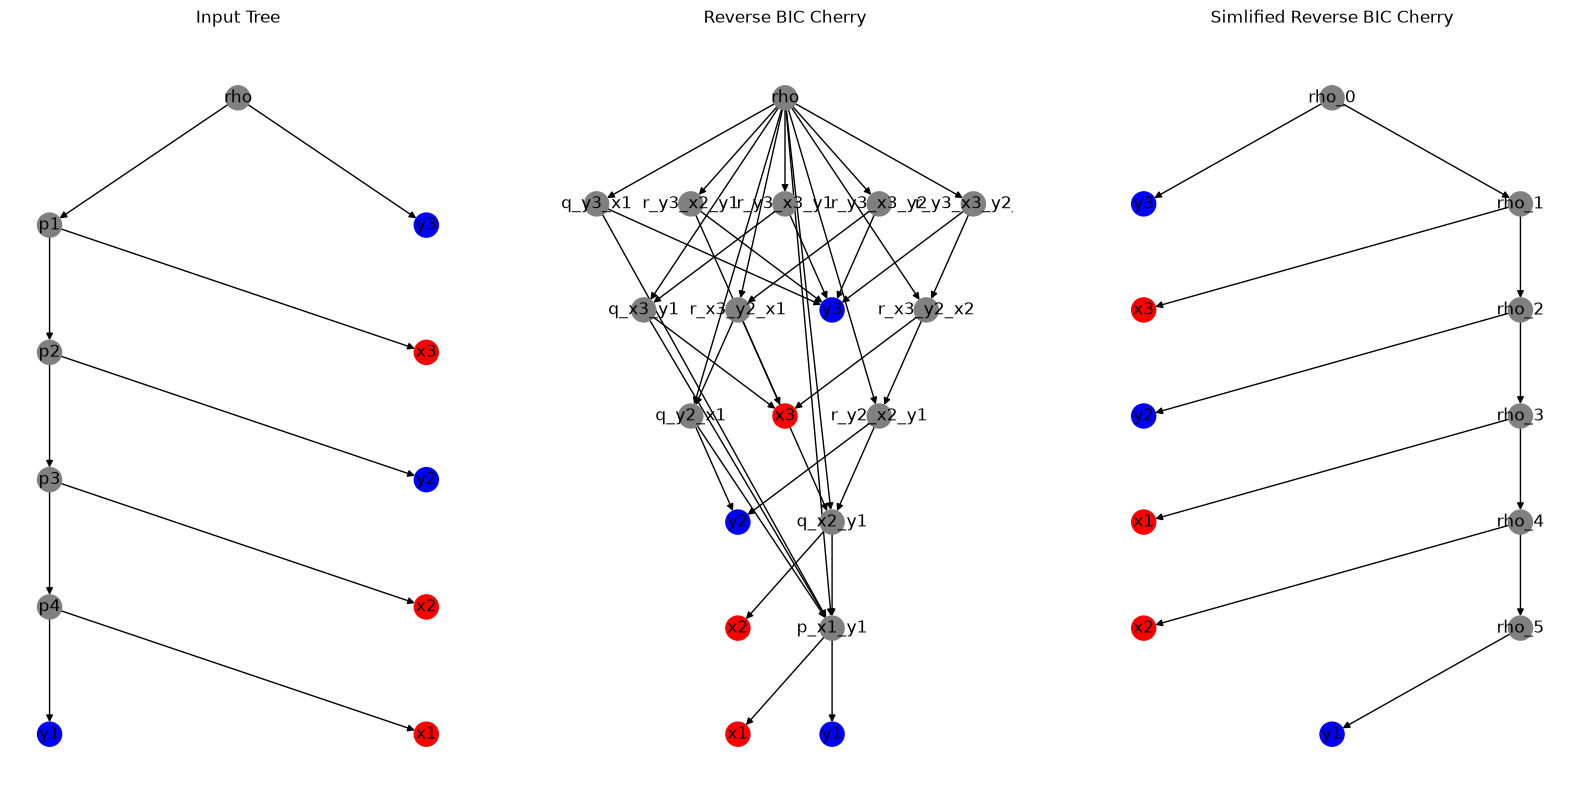

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# input tree
big_lrt = nx.DiGraph()
big_lrt.add_nodes_from([("x1", {"color": "red"}), ("x2", {"color": "red"}), ("x3", {"color": "red"}), ("y1", {"color": "blue"}), ("y2", {"color": "blue"}), ("y3", {"color": "blue"})])
big_lrt.add_edges_from([("p4", "y1"), ("p4", "x1"), ("p3", "p4"), ("p3", "x2"),
                        ("p2", "p3"), ("p2", "y2"), ("p1", "p2"), ("p1", "x3"), ("rho", "p1"), ("rho", "y3")])

pos = layered_layout(big_lrt)
nodes_list, nodes_colors = zip(*big_lrt.nodes(data="color", default="grey"))
nx.draw(big_lrt, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[0])
axes[0].set_title("Input Tree")

# input BMG
input_BMG = bmg(big_lrt, mode="weak")
#pos_BMG = nx.spring_layout(input_BMG)
#nodes_list, nodes_colors = zip(*input_BMG.nodes(data="color", default="grey"))
#nx.draw(input_BMG, pos_BMG, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0,1], with_labels=True, arrows=True, arrowsize=12,
#        connectionstyle="arc3,rad=0.15",)
#axes[0,1].set_title("Input BMG")

# reverse Bic cherry
reverse_cherry = BICcherry_reverse(input_BMG, simplify=False)

pos = layered_layout(reverse_cherry)
nodes_list, nodes_colors = zip(*reverse_cherry.nodes(data="color", default="grey"))
nx.draw(reverse_cherry, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[1])
axes[1].set_title("Reverse BIC Cherry")

# reverse BMG
#reverse_BMG = bmg(reverse_cherry, mode="weak")
#nodes_list, nodes_colors = zip(*reverse_BMG.nodes(data="color", default="grey"))
#nx.draw(reverse_BMG, pos_BMG, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,1], with_labels=True, arrows=True, arrowsize=12,
#        connectionstyle="arc3,rad=0.15",)
#axes[1,1].set_title("Reverse BMG")

# simple reverse Bic cherry
simple_cherry = BICcherry_reverse(input_BMG, simplify=True)

pos = layered_layout(simple_cherry)
nodes_list, nodes_colors = zip(*simple_cherry.nodes(data="color", default="grey"))
nx.draw(simple_cherry, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[2])
axes[2].set_title("Simlified Reverse BIC Cherry")

#fig.savefig("../Presentation/figures/explain_simplified.svg", bbox_inches="tight")

In [11]:

test_BMG = nx.DiGraph()
test_BMG.add_nodes_from([("x1", {"color": "red"}), ("x2", {"color": "red"}), ("y1", {"color": "blue"}), ("y2", {"color": "blue"}), ("y3", {"color": "blue"})])
test_BMG.add_edges_from([("x1", "y1"), ("y1", "x1"), ("x1", "y3"), ("y3", "x1"),
                        ("x2", "y2"), ("y2", "x1"), ("x2", "y1")])
"""
test_BMG.add_nodes_from([("x1", {"color": "red"}), ("x2", {"color": "red"}), ("y1", {"color": "blue"}), ("y2", {"color": "blue"}), ("z1", {"color": "green"})])
test_BMG.add_edges_from([("x1", "y1"), ("y1", "x1"), ("x2", "y1"), ("y2", "x2"),
                        ("x1", "z1"), ("y1", "z1"), ("x2", "z1"), ("y2", "z1"),
                        ("z1", "x1"), ("z1", "y1"), ("z1", "x2"), ("z1", "y2")])"""

'\ntest_BMG.add_nodes_from([("x1", {"color": "red"}), ("x2", {"color": "red"}), ("y1", {"color": "blue"}), ("y2", {"color": "blue"}), ("z1", {"color": "green"})])\ntest_BMG.add_edges_from([("x1", "y1"), ("y1", "x1"), ("x2", "y1"), ("y2", "x2"),\n                        ("x1", "z1"), ("y1", "z1"), ("x2", "z1"), ("y2", "z1"),\n                        ("z1", "x1"), ("z1", "y1"), ("z1", "x2"), ("z1", "y2")])'

In [12]:
# creating the bic Cherry from the networks paper, figure 2 b
bic_cherry = nx.DiGraph()
bic_cherry.add_nodes_from([("y", {"color": "red"}), ("x", {"color": "blue"}), ("z", {"color": "red"})])
bic_cherry.add_edges_from([("rho", "Pxy"), ("Pxy", "y"), ("Pxy", "x"), ("Pxy", "Qxz"), ("Qxz", "x"), ("Qxz", "z"),
                           ("rho", "Pxz"), ("Pxz", "z"), ("Pxz", "x"), ("Pxz", "Qxy"), ("Qxy", "x"), ("Qxy", "y")])

Text(0.5, 1.0, 'Weak BMG')

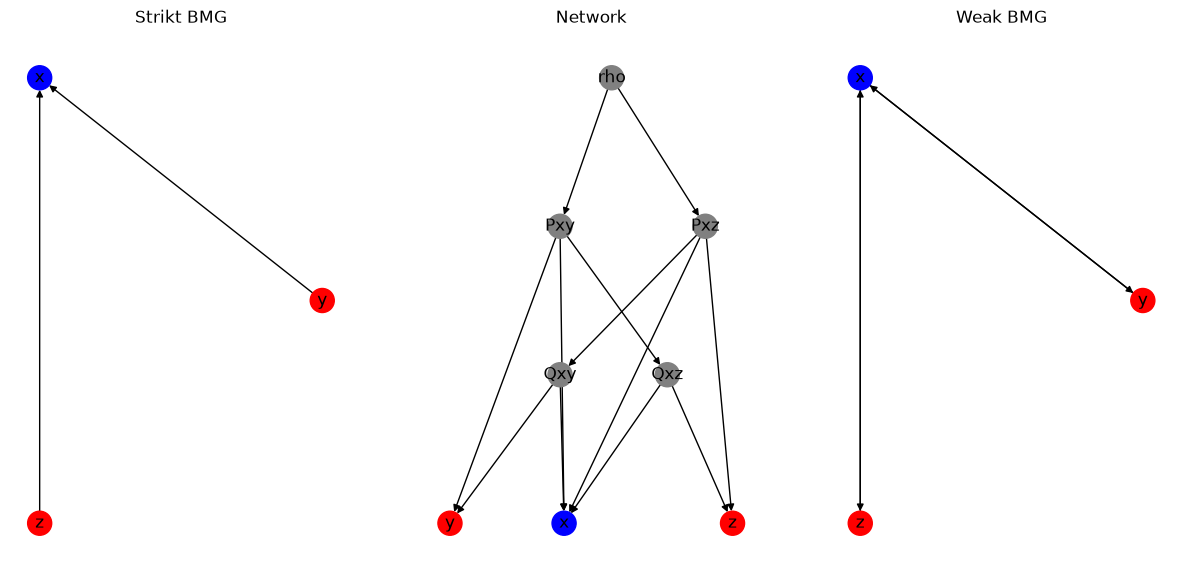

In [13]:
# figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
pos = graphviz_layout(bic_cherry, prog="dot")
nodes_list, nodes_colors = zip(*bic_cherry.nodes(data="color", default="grey"))
nx.draw(bic_cherry, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels = True)
axes[1].set_title("Network")

# strong bmg
strong_bmg = bmg(bic_cherry, mode="strong")
pos = nx.circular_layout(strong_bmg)
nodes_list, nodes_colors = zip(*strong_bmg.nodes(data="color", default="grey"))
nx.draw(strong_bmg, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0], with_labels=True)
axes[0].set_title("Strikt BMG")

# weak BMG
weak_bmg = bmg(bic_cherry, mode="weak")
nx.draw(weak_bmg, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[2], with_labels=True)
axes[2].set_title("Weak BMG")

### Check if a modified version of the BIC-cherry + expansion procedure yields networks that explain weak best match graphs.

# Tasks

## Use `AsymmeTree` to generate trees. 
Modify the resulting trees by inserting hybridization vertices to generate phylogenetic networks (iteratively choosing two random points on edges of the tree/network and connecting them).

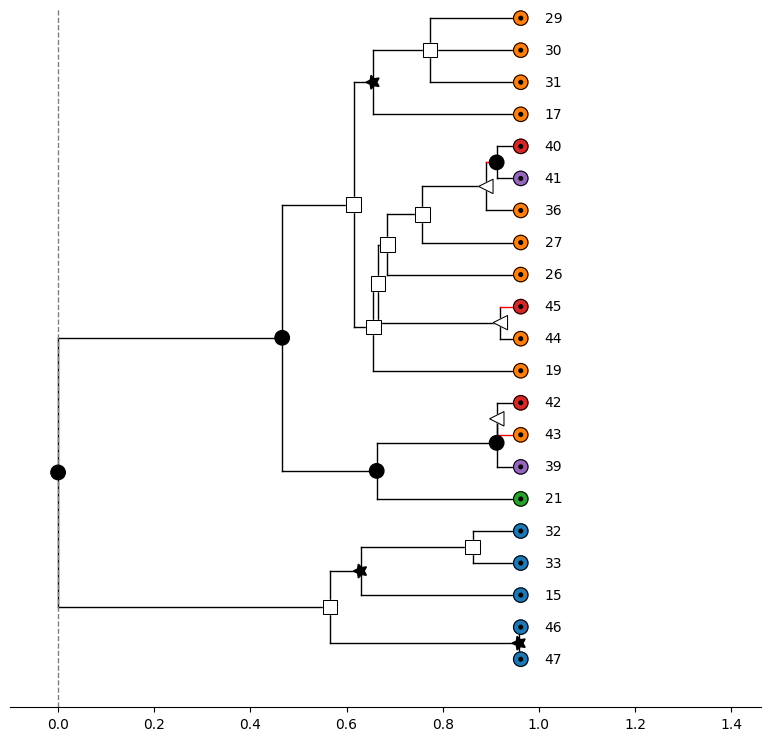

In [18]:
def generateTree(seed:int = None, nSpecies:int = 2):

    if seed:
        # Setze den Seed für Pythons Standard-Zufallsfunktionen
        random.seed(seed)
        # Setze den Seed für NumPys Zufallsfunktionen (wichtig für AsymmeTree)
        np.random.seed(seed)

    # species tree
    speciesTree = te.species_tree_n_age(
        age = 1.0,
        n = nSpecies
        #, contraction_probability=0.0, contraction_proportion=0.2, contraction_bias="exponential"
    )
    # gene tree
    T = te.dated_gene_tree(
        speciesTree, dupl_rate=1.0, loss_rate=0.1, hgt_rate=0.3, gc_rate=0.2, prohibit_extinction="per_species", dupl_polytomy=0.5
    )
    # prune all loss branches and the planted root
    geneTree = te.prune_losses(T)
    
    return speciesTree, geneTree

speciesTree, geneTree = generateTree(nSpecies= 5)

species_colors, gene_colors = assign_colors(speciesTree, geneTree)

# visualize asymetree tree
visualize(geneTree, color_dict=gene_colors)

## Construction of explaining networks:
1. Implement the BIC-cherry+expansion algorithm for given graphs $(G, \sigma)$ as in the tech report from Patricia Ebert and Marc Hellmuth.
2. Modify this algorithm by restricting expansions $[xy : xz]$ to accepting edges $xz$ in graph $(G, \sigma)$ and possibly relabel $q_{xz}$ as $p_{xz}$
3. Thoroughly test these algorithms! Think of unit tests for your implementations!
4. Test if variant (b) always yields an explanation for weak best matches: to this end, generate a network $(N, \sigma)$, compute its weak best match graph, run variant (b) to produce an explaining network $(N', \sigma)$, and check that the weak best match graph of $(N', \sigma)$ coincides with the weak best match graph of $(N, \sigma)$. If this turns out to be not true, find the minimal examples where the networks differ.

## Simplification of explaining networks
1. Construct tree-BMGs $(G, \sigma)$ from (`AsymmeTree`-generated) trees and compute their least resolved trees $T∗$ . This is the target.
2. Take the tree-BMGs from (a) and construct the BIC-cherry+expansion explanations $(N, \sigma)$.
3. Implement graph editing by “pulling up” or “pulling down” edges, and removing vertices with the same parents and children, as described in class.
4. Check both for single moves and combinations of a small number of moves whether the modified network $(N', \sigma)$ has the same (weak) best match graph as $(N, \sigma)$.
5. Devise heuristics to search for edit paths that allow the stepwise conversion of the BIC-cherry+expansion explanations of (N, σ) in the least resolved tree-explanation (lrt) $T∗$.
6. If this is not always successful, find minimal examples that fail, try to find out why they fail, and if possible use this information to improve the heuristic for editing schedules.

# Interpretation
Try to find out why and where simple approaches fail (as e.g. in 2f) and make recommendation for further improvements/modifications.